# Notebook 07 - Visualisation finale

Nous rassemblons les r?sultats principaux pour pr?parer la pr?sentation.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "car" / "car-11"
IMG_DIR = DATA_DIR / "img"
RESULTS_DIR = PROJECT_ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "plots"
FRAMES_DIR = RESULTS_DIR / "frames_output"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
FRAMES_DIR.mkdir(parents=True, exist_ok=True)

print("Racine du projet:", PROJECT_ROOT)

import cv2
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.preprocessing import load_image, load_image_sequence
from src.trajectory import load_trajectory_csv, compute_groundtruth_centers
from src.analysis import compute_motion_analysis
from src.visualization import (
    plot_trajectory,
    plot_trajectory_on_frame,
    plot_speed,
    plot_direction,
    plot_comparison_with_groundtruth,
)

Racine du projet: c:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\motion-estimation-project


## Champ de mouvement

Nous avons utilis? Lucas-Kanade pour estimer le d?placement des points caract?ristiques de la voiture. Les vecteurs obtenus forment un champ de mouvement sparse.

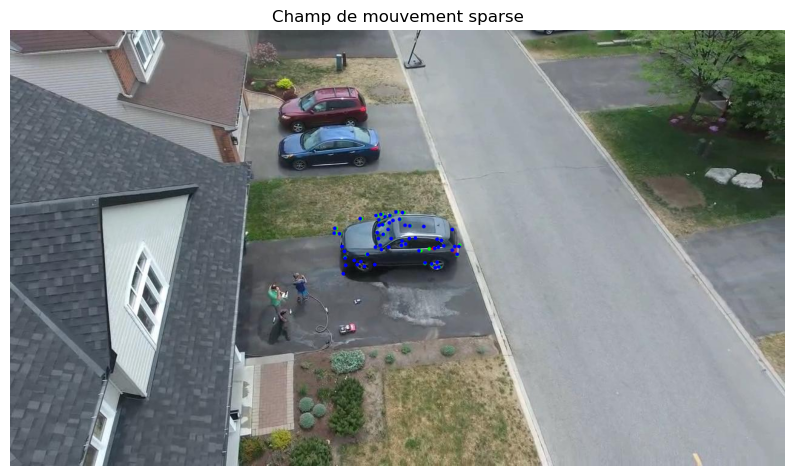

In [2]:
motion_field_path = FRAMES_DIR / "motion_field_frame.png"
if motion_field_path.exists():
    motion_field = cv2.imread(str(motion_field_path))
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(motion_field, cv2.COLOR_BGR2RGB))
    plt.title("Champ de mouvement sparse")
    plt.axis("off")
    plt.show()
else:
    print("Executez d'abord le notebook 04 pour generer motion_field_frame.png")

Nous observons le champ de mouvement sparse : seuls les points caract?ristiques d?tect?s poss?dent un vecteur.

## Trajectoire globale

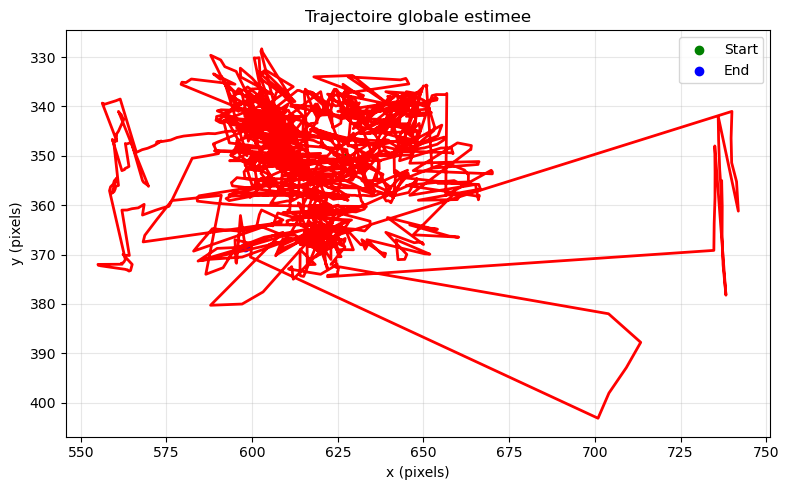

In [3]:
trajectory_df = load_trajectory_csv(RESULTS_DIR / "trajectory_estimated.csv")
fig = plot_trajectory(trajectory_df, save_path=PLOTS_DIR / "trajectory_2d.png")
plt.show()

Nous avons calcul? le centre robuste de l'objet ? chaque frame ? partir des points suivis. La succession de ces centres repr?sente la trajectoire globale de la voiture.

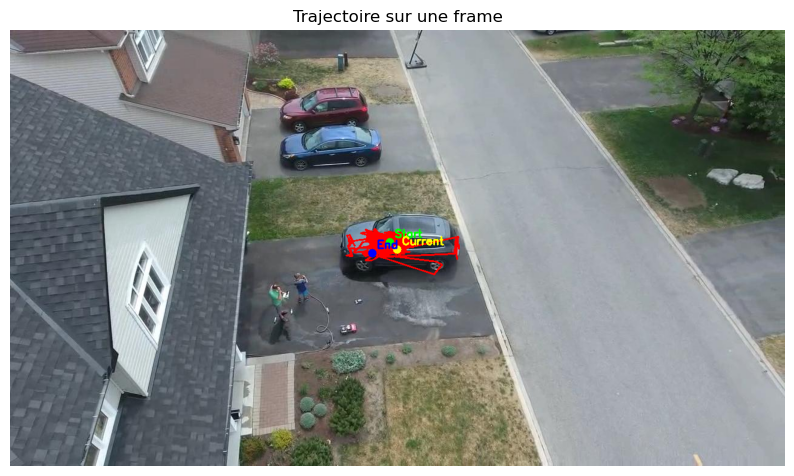

In [4]:
image_paths = load_image_sequence(IMG_DIR)
frame_for_trajectory = load_image(image_paths[0])
trajectory_frame = plot_trajectory_on_frame(frame_for_trajectory, trajectory_df, save_path=FRAMES_DIR / "trajectory_on_frame.png")
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(trajectory_frame, cv2.COLOR_BGR2RGB))
plt.title("Trajectoire sur une frame")
plt.axis("off")
plt.show()

Nous observons la trajectoire en rouge. Start est en vert, Current en jaune et End en bleu.

## Vitesse et direction

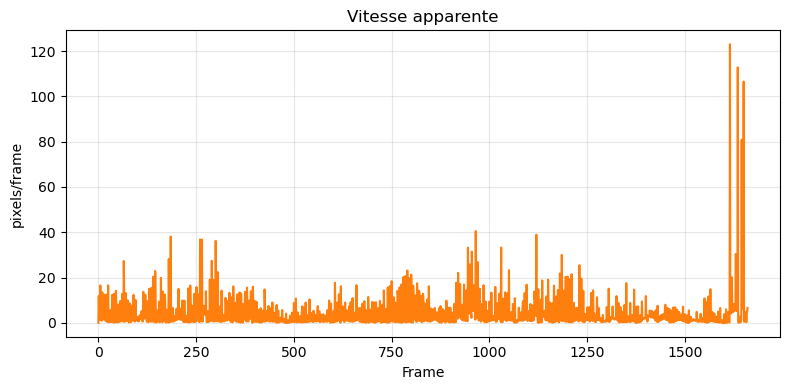

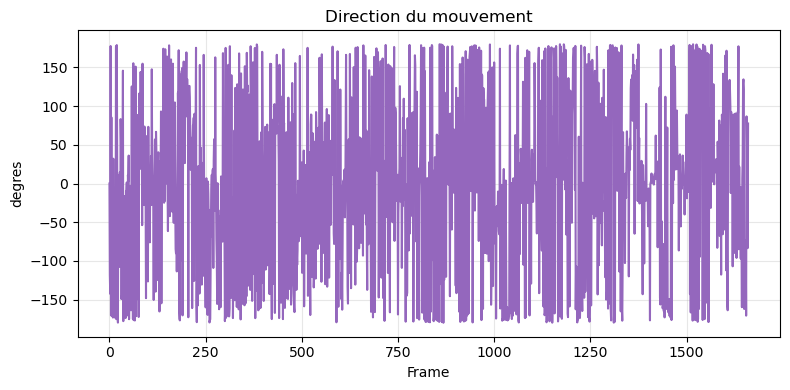

In [5]:
analysis_path = RESULTS_DIR / "motion_analysis_estimated.csv"
if analysis_path.exists():
    motion_df = pd.read_csv(analysis_path)
else:
    motion_df = compute_motion_analysis(trajectory_df)

fig = plot_speed(motion_df, save_path=PLOTS_DIR / "speed_curve.png")
plt.show()
fig = plot_direction(motion_df, save_path=PLOTS_DIR / "direction_curve.png")
plt.show()

Nous avons calcul? `dx`, `dy`, la distance, la vitesse apparente en pixels/frame et la direction avec `atan2`.

## Comparaison avec groundtruth

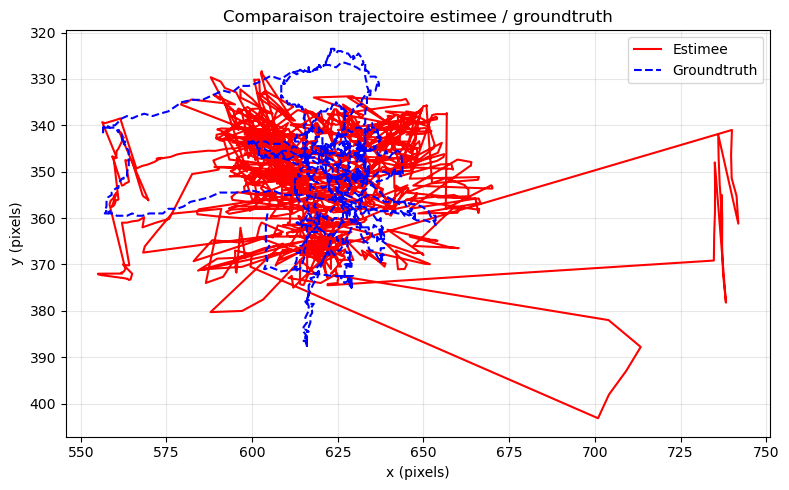

In [6]:
gt_df = compute_groundtruth_centers(DATA_DIR / "groundtruth.txt")
fig = plot_comparison_with_groundtruth(trajectory_df, gt_df, save_path=PLOTS_DIR / "comparison_groundtruth.png")
plt.show()

Nous interpr?tons cette comparaison comme une ?valuation finale. Elle ne remplace pas notre m?thode de suivi.

## Conclusion finale

1. Nous avons estim? le champ de mouvement avec Lucas-Kanade.
2. Nous avons extrait la trajectoire globale avec le centre robuste.
3. Nous avons analys? la vitesse et la direction ? partir des d?placements du centre.

Nous avons aussi discut? les hypoth?ses : rigidit? de la voiture, petits d?placements entre frames et illumination presque constante.